<a href="https://colab.research.google.com/github/ajaygupta777/Hotel-Booking-Analysis-/blob/main/Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('/content/cleaned_hotel_bookings.csv')

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,planner_type,total_stay,guest_type
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,Early Planner,0,New
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,Early Planner,0,New
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,Last Minute,1,New
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,Last Minute,1,New
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,Last Minute,2,New


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119387 entries, 0 to 119386
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119387 non-null  object 
 1   is_canceled                     119387 non-null  int64  
 2   lead_time                       119387 non-null  int64  
 3   arrival_date_year               119387 non-null  int64  
 4   arrival_date_month              119387 non-null  object 
 5   arrival_date_week_number        119387 non-null  int64  
 6   arrival_date_day_of_month       119387 non-null  int64  
 7   stays_in_weekend_nights         119387 non-null  int64  
 8   stays_in_week_nights            119387 non-null  int64  
 9   adults                          119387 non-null  int64  
 10  children                        119387 non-null  float64
 11  babies                          119387 non-null  int64  
 12  meal            

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay
count,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,...,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000,119387.000000
mean,0.370417,104.013728,2016.156558,27.165345,15.798228,0.927622,2.500339,1.856408,0.103889,0.007949,...,0.087120,0.137092,0.221121,74.828767,10.775428,2.321208,101.779922,0.062511,0.571377,3.427961
std,0.482918,106.863413,0.707473,13.605226,8.780877,0.998615,1.908295,0.579263,0.398560,0.097437,...,0.844347,1.497453,0.652309,107.142649,53.944534,17.594938,48.125104,0.245279,0.792803,2.557442
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,94.560000,0.000000,0.000000,3.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000,4.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,451.500000,8.000000,5.000000,69.000000


In [8]:
df.shape

(119387, 35)

In [9]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


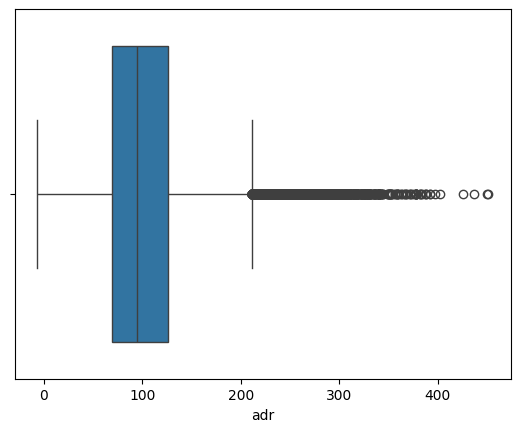

In [10]:
sns.boxplot(x=df['adr'])
plt.show()

In [11]:
df = df[df['adr'] < 500]

In [12]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [13]:
df['guest_type'] = np.where(df['is_repeated_guest']==1,
                            'Repeated',
                            'New')

In [15]:
df.to_csv('/content/cleaned_hotel_bookings.csv', index=False)

In [17]:
df = pd.read_csv('/content/cleaned_hotel_bookings.csv')

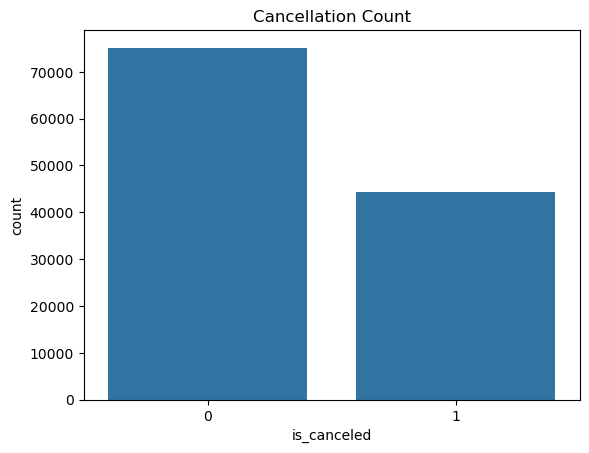

In [ ]:
sns.countplot(x='is_canceled', data=df)
plt.title('Cancellation Count')
plt.show()

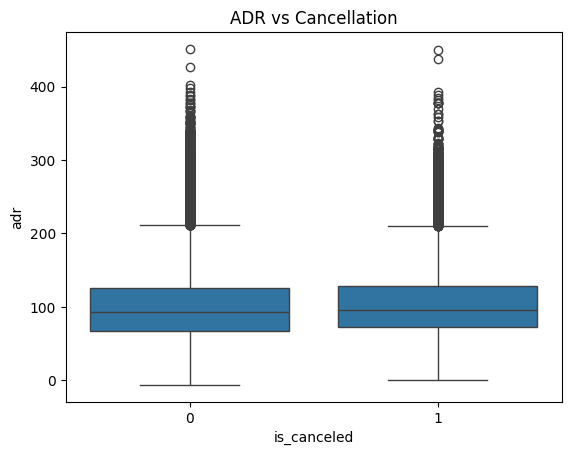

In [18]:
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title('ADR vs Cancellation')
plt.show()

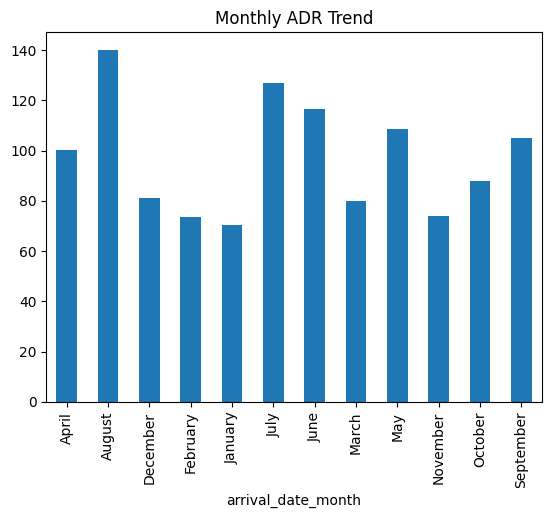

In [19]:
monthly = df.groupby('arrival_date_month')['adr'].mean()

monthly.plot(kind='bar')
plt.title('Monthly ADR Trend')
plt.show()

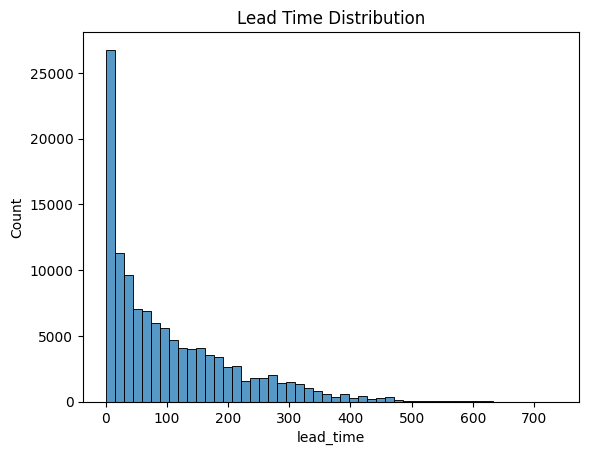

In [20]:
sns.histplot(df['lead_time'], bins=50)
plt.title('Lead Time Distribution')
plt.show()

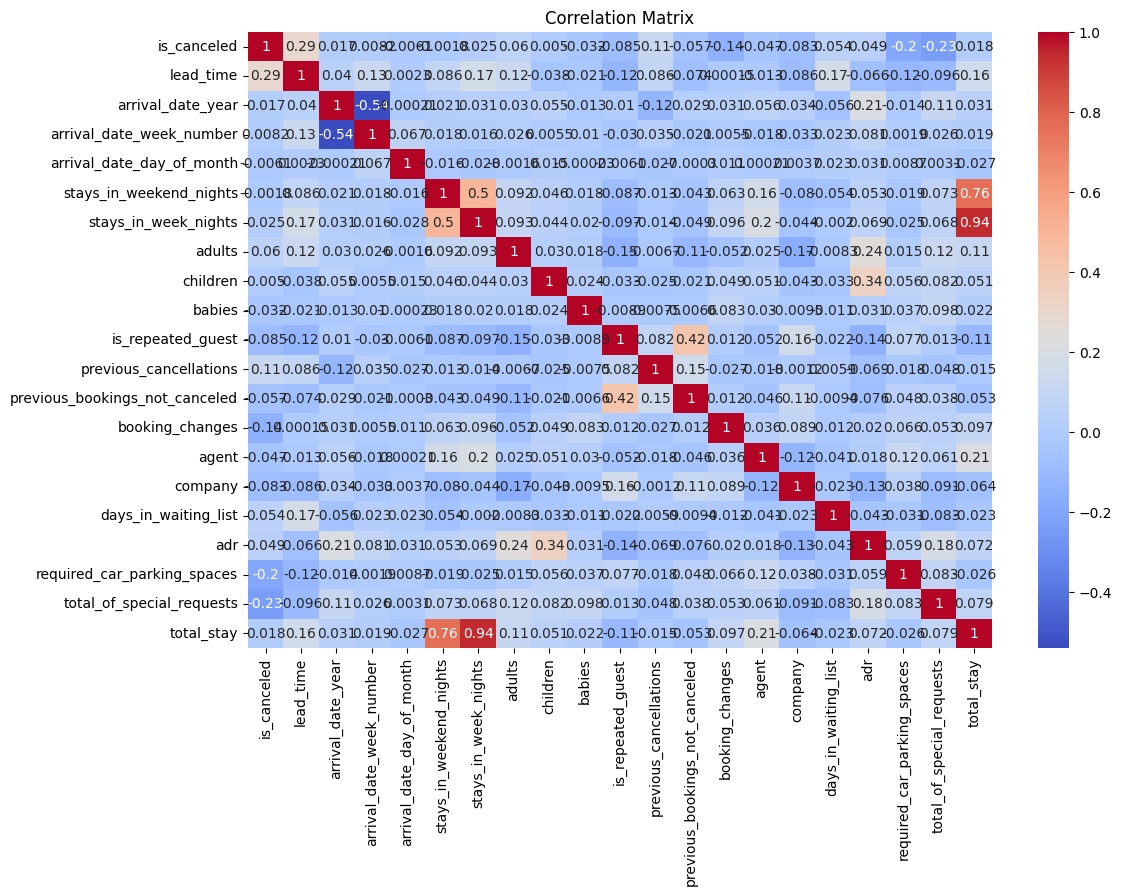

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [22]:
df['planner_type'] = np.where(df['lead_time'] > 90,
                              'Early Planner',
                              'Last Minute')

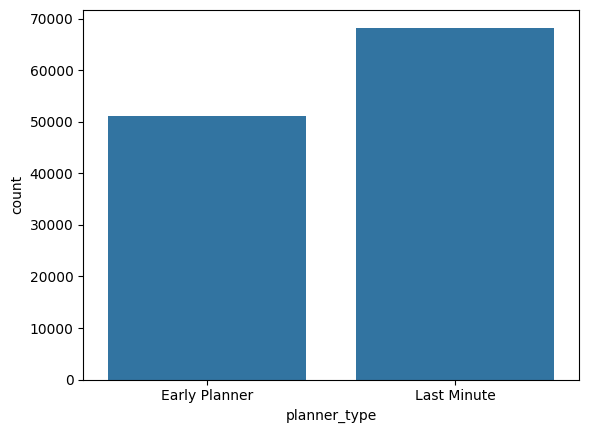

In [23]:
sns.countplot(x='planner_type', data=df)
plt.show()